# PHT3D Example 7 — MF6PQC validation

The benchmark profiles are generated directly from the official PHT3D 2.10 Example 7 inputs. The first figure reproduces the five profile panels in the official example; the second figure shows the pointwise MF6PQC–PHT3D differences.

In [2]:
import os
import sys
from pathlib import Path

sys.dont_write_bytecode = True
_name = "PHT3D_E07"
_candidates = [
    p for base in (Path.cwd(), *Path.cwd().parents) for p in (base, base / "examples" / _name)
]
CASE_DIR = next(
    (p.resolve() for p in _candidates if p.name == _name and (p / "modflow_model.py").is_file()),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{_name} from {Path.cwd()}")
os.chdir(CASE_DIR)
sys.path.insert(0, str(CASE_DIR))
__file__ = str(CASE_DIR / "plot.ipynb")
OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"

# Saved numerical outputs are distributed losslessly; solver logs are omitted.
import zipfile

for _kind in ("output", "simulation"):
    _base = CASE_DIR / _kind
    for _archive in sorted(_base.glob("saved_results*.zip")):
        with zipfile.ZipFile(_archive) as _zip:
            for _member in _zip.infolist():
                _target = (_base / _member.filename).resolve()
                if not _target.is_relative_to(_base.resolve()):
                    raise ValueError("Archive member escapes the case directory")
                if not _target.exists():
                    _zip.extract(_member, _base)

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_case_dir():
    candidates = [Path.cwd(), Path.cwd() / "examples" / "PHT3D_E07"]
    for candidate in candidates:
        if (candidate / "output" / "results.npy").is_file():
            return candidate
    raise FileNotFoundError("Run examples/PHT3D_E07/run.py before plotting.")


case_dir = find_case_dir()
results = np.load(case_dir / "output" / "results.npy")
headings = np.loadtxt(case_dir / "output" / "results_headings.txt", dtype=str, ndmin=1).tolist()
expected_headings = ["S_a", "S_b", "S_c", "S_cc", "S_ccc"]
if headings != expected_headings:
    raise ValueError(f"Unexpected result headings: {headings}")
if results.ndim != 3 or results.shape[1:] != (5, 41):
    raise ValueError(f"Unexpected results shape: {results.shape}")

with np.load(case_dir / "input_data" / "official_reference.npz") as reference:
    x_m = reference["x_m"]
    official = np.vstack([reference[name] for name in ("s_a", "s_b", "s_c", "s_cc", "s_ccc")])

# Both arrays are stored in mol/L; the official example plots values ×1000.
mf6pqc = results[-1] * 1000.0
official = official * 1000.0
species_titles = ["Species A", "Species B", r"Species C$_1$", r"Species C$_2$", r"Species C$_3$"]
ylabels = ["A", "B", r"C$_1$", r"C$_2$", r"C$_3$"]
ylimits = [(0.0, 1.0), (0.0, 0.2), (0.0, 0.06), (0.0, 0.04), (0.0, 0.02)]

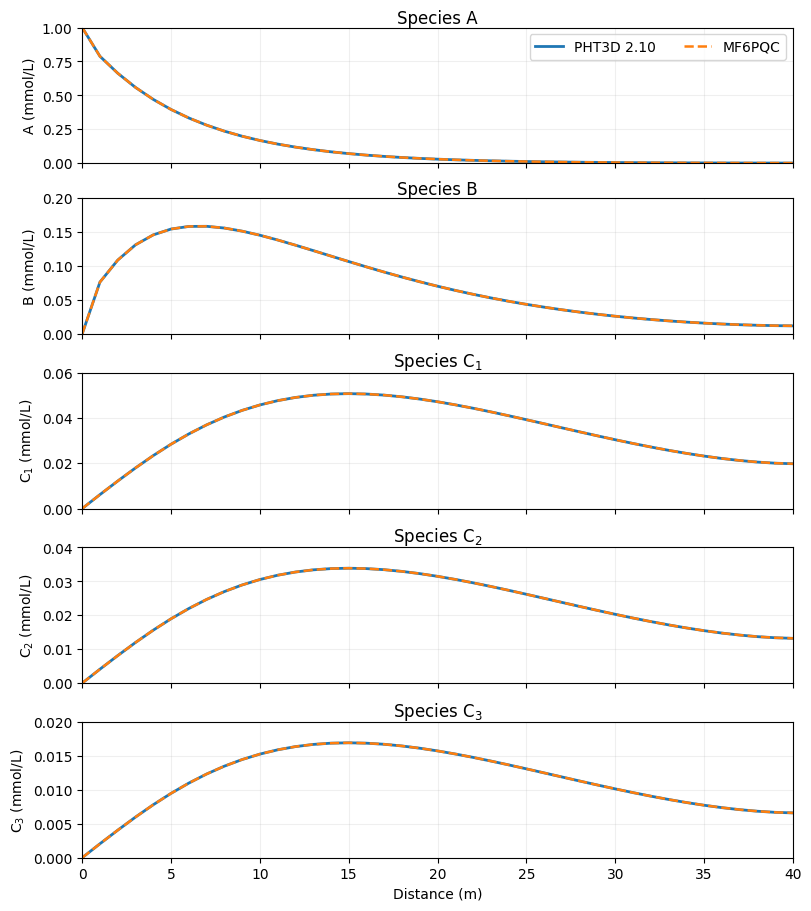

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(8, 9), sharex=True, constrained_layout=True)

for index, ax in enumerate(axes):
    ax.plot(x_m, official[index], color="tab:blue", linewidth=2.0, label="PHT3D 2.10")
    ax.plot(x_m, mf6pqc[index], "--", color="tab:orange", linewidth=1.8, label="MF6PQC")
    ax.set_title(species_titles[index], pad=3)
    ax.set_ylabel(f"{ylabels[index]} (mmol/L)")
    ax.set_xlim(0.0, 40.0)
    ax.set_ylim(*ylimits[index])
    ax.grid(alpha=0.2)

axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("Distance (m)")
# profile_path = case_dir / "output" / "profile_comparison.png"
# fig.savefig(profile_path, dpi=180, bbox_inches="tight")
plt.show()

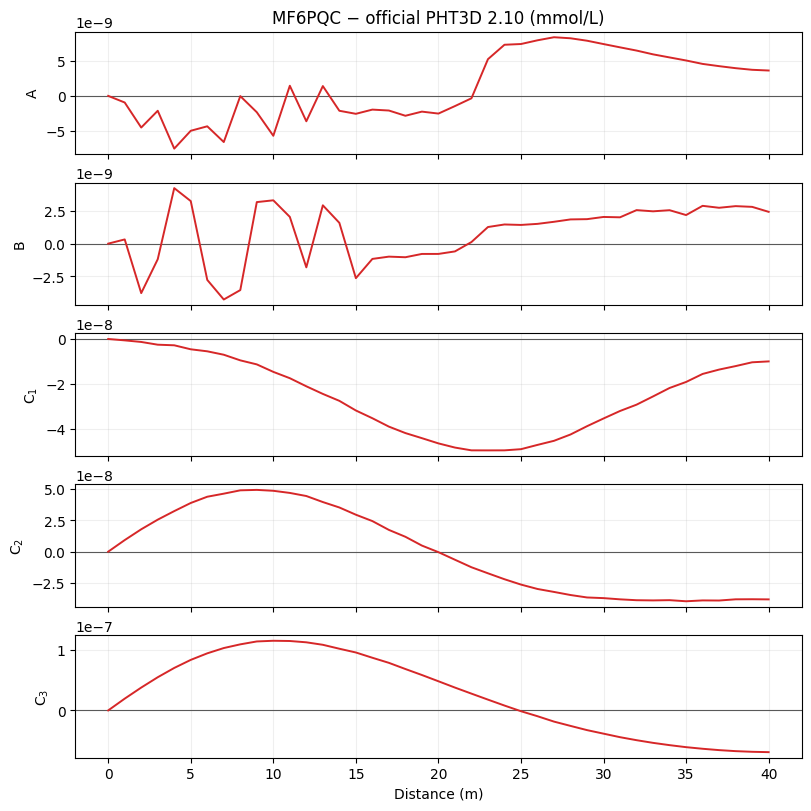

In [5]:
difference = mf6pqc - official
fig, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True, constrained_layout=True)

for index, ax in enumerate(axes):
    ax.axhline(0.0, color="0.35", linewidth=0.8)
    ax.plot(x_m, difference[index], color="tab:red", linewidth=1.4)
    ax.set_ylabel(ylabels[index])
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(alpha=0.2)

axes[0].set_title("MF6PQC − official PHT3D 2.10 (mmol/L)")
axes[-1].set_xlabel("Distance (m)")

plt.show()

In [6]:
rmse = np.sqrt(np.mean(difference**2, axis=1))
max_abs = np.max(np.abs(difference), axis=1)
rows = [
    f"| {name} | {rmse[index]:.3e} | {max_abs[index]:.3e} |"
    for index, name in enumerate(expected_headings)
]
display(
    Markdown(
        "| Species | RMSE (mmol/L) | Maximum absolute error (mmol/L) |\n"
        "|:--|--:|--:|\n" + "\n".join(rows)
    )
)
print("Saved figures:\n- output/profile_comparison.png\n- output/profile_difference.png")

| Species | RMSE (mmol/L) | Maximum absolute error (mmol/L) |
|:--|--:|--:|
| S_a | 4.867e-09 | 8.345e-09 |
| S_b | 2.327e-09 | 4.265e-09 |
| S_c | 3.028e-08 | 4.971e-08 |
| S_cc | 3.367e-08 | 4.947e-08 |
| S_ccc | 6.924e-08 | 1.145e-07 |

Saved figures:
- output/profile_comparison.png
- output/profile_difference.png
